[![UAEM](https://www.uaem.mx/fcaei/images/uaem.png)](https://www.uaem.mx/fcaei/moca.html)
[![Python 3.9](https://img.shields.io/badge/Python-3.9-blue.svg)](https://www.python.org/downloads/release/python-390/)
[![Status](https://img.shields.io/badge/Status-En%20Progreso-yellow.svg)]()

# Práctica 2: Análisis Estadístico y Regresión OLS con el dataset `tips`

**Alumno:** Emiliano Rodriguez Villegas

**Fecha:** 12 de Septiembre de 2025
**Versión:** 1.0

---

## Introducción y Objetivo

Este notebook aborda un análisis completo del dataset `tips`, el cual contiene información sobre propinas en un restaurante. El objetivo de la práctica es aplicar un flujo de trabajo de análisis de datos que abarca desde la estadística descriptiva hasta la construcción y diagnóstico de modelos de regresión lineal (OLS).

Se explorarán las relaciones entre el monto de la propina y otras variables como el total de la cuenta, el tamaño del grupo y el día de la semana, para finalmente modelar estos comportamientos.

---

### Índice General del Notebook

1.  [**Fase 1: Preparación y Análisis Descriptivo**](#fase-1)
    * [1.1. Carga de Librerías y Dataset](#1-1)
    * [1.2. Exploración Inicial de los Datos](#1-2)
    * [1.3. Estadística Descriptiva](#1-3)
2.  [**Fase 2: Análisis Exploratorio de Datos (EDA)**](#fase-2)
    * [2.1. Análisis de Variables Categóricas](#2-1)
    * [2.2. Análisis de Variables Numéricas (Distribuciones)](#2-2)
    * [2.3. Relación entre Variables (Gráficos Bivariados)](#2-3)
3.  [**Fase 3: Análisis de Correlación**](#fase-3)
    * [3.1. Matriz de Covarianza](#3-1)
    * [3.2. Correlación de Pearson](#3-2)
    * [3.3. Correlación de Spearman y Kendall](#3-3)
    * [3.4. Visualización de Correlaciones (Heatmap)](#3-4)
4.  [**Fase 4: Modelado con Regresión Lineal (OLS)**](#fase-4)
    * [4.1. Regresión Lineal Simple](#4-1)
    * [4.2. Regresión Lineal Múltiple](#4-2)
    * [4.3. Interpretación de los Coeficientes del Modelo](#4-3)
5.  [**Fase 5: Diagnóstico del Modelo y Conclusiones**](#fase-5)
    * [5.1. Análisis de Supuestos de OLS](#5-1)
 

---

## <a id='fase-1'></a>Fase 1: Preparación y Análisis Descriptivo

En esta primera fase, cargaremos las librerías necesarias y el dataset `tips`. Luego, realizaremos una exploración inicial y calcularemos las estadísticas descriptivas para tener una primera visión general de los datos.

### <a id='1-1'></a>1.1. Carga de Librerías y Dataset

Importamos las librerías que usaremos y cargamos el conjunto de datos `tips` directamente desde la librería Seaborn.



In [5]:

import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


tipsDF = sns.load_dataset("tips")

<a id='1-2'></a>1.2. Exploración Inicial de los Datos

In [6]:
tipsDF.head()


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [7]:
tipsDF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [10]:
## var cuanntitativas
tipsDF.describe()


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


## <a id='fase-2'></a>Fase 2: Análisis Exploratorio de Datos 

Visualizaremos los datos para entender mejor las distribuciones de las variables individuales y las relaciones que existen entre ellas. Esto es fundamental antes de pasar a la correlación y la regresión.

### <a id='2-1'></a>2.1. Análisis de Variables Categóricas

Analizamos la frecuencia de cada categoría en las variables no numéricas para entender la composición de la clientela y las condiciones del servicio.


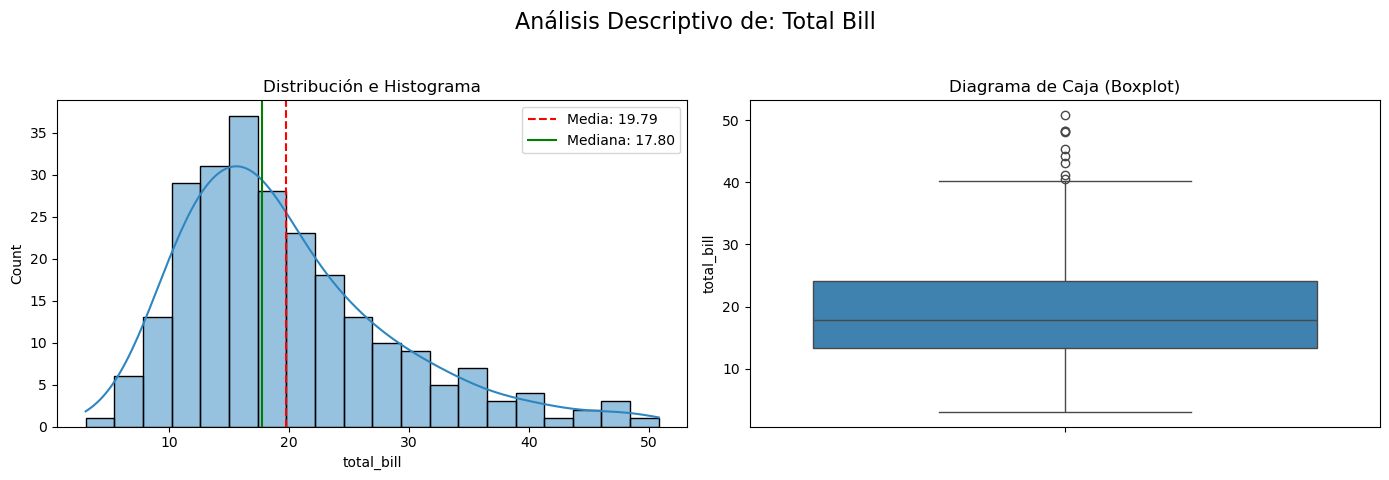

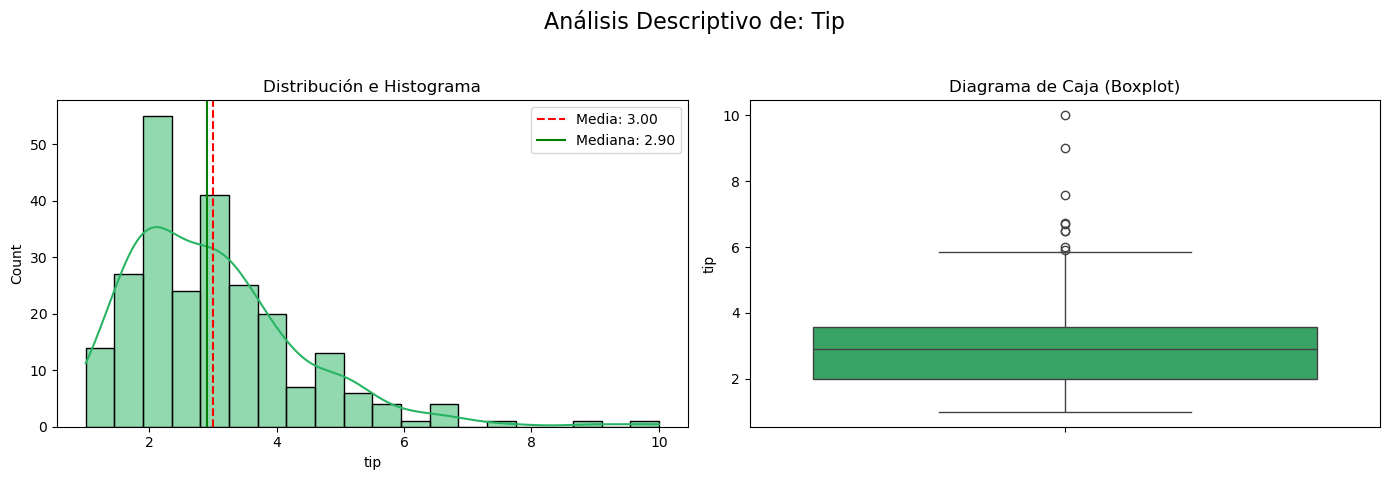

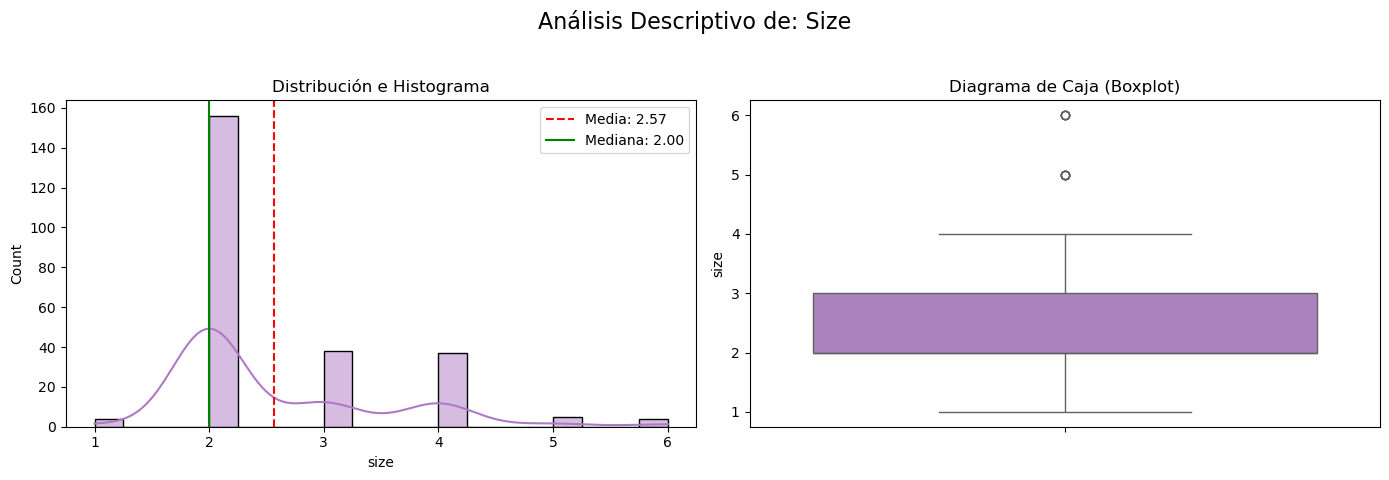

In [26]:

columnasNumericas = ['total_bill', 'tip', 'size']
colores = ['#2E86C1', '#28B463', '#AF7AC5'] 

for i, col in enumerate(columnasNumericas):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Análisis Descriptivo de: {col.replace("_", " ").title()}', fontsize=16)
    
    # histograma y distribución
    sns.histplot(ax=axes[0], data=tipsDF, x=col, kde=True, color=colores[i], bins=20)
    axes[0].set_title('Distribución e Histograma')

    media = tipsDF[col].mean()
    mediana = tipsDF[col].median()
    axes[0].axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
    axes[0].axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:.2f}')
    axes[0].legend()
    
    # boxplot
    sns.boxplot(ax=axes[1], data=tipsDF, y=col, color=colores[i])
    axes[1].set_title('Diagrama de Caja (Boxplot)')
    
    # ajustar
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajuste para el suptitle
    plt.show()

---

## <a id='fase-3'></a>Fase 3: Análisis de Correlación

En esta fase, cuantificaremos la relación entre las variables numéricas. El análisis de correlación es un paso previo fundamental a la regresión, ya que nos indica qué variables están más fuertemente asociadas.

### <a id='3-1'></a>3.1. Matriz de Covarianza

La covarianza mide la dirección de la relación lineal entre dos variables. Un valor positivo indica una relación directa (ambas suben), y uno negativo, una relación inversa.



In [35]:

variablesNumericas = tipsDF.select_dtypes(include=np.number)

matrizCovarianza = variablesNumericas.cov()

matrizCovarianza

,total_bill,tip,size,log_tip
total_bill,79.252939,8.323502,5.065983,2.529164
tip,8.323502,1.914455,0.643906,0.576628
size,5.065983,0.643906,0.904591,0.199618
log_tip,2.529164,0.576628,0.199618,0.190236


<a id='3-2'></a>3.2. Correlación de Pearson

La correlación de Pearson estandariza la covarianza a un valor entre -1 y 1, lo que facilita su interpretación. Mide la fuerza y dirección de la relación lineal.

In [18]:
matrizPearson = variablesNumericas.corr(method='pearson')

print("Matriz de Correlación de Pearson:")
matrizPearson

Matriz de Correlación de Pearson:


,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [19]:
matrizSpearman = variablesNumericas.corr(method='spearman')

print("Matriz de Correlación de Spearman:")
matrizSpearman

Matriz de Correlación de Spearman:


,total_bill,tip,size
total_bill,1.000000,0.678968,0.604791
tip,0.678968,1.000000,0.468268
size,0.604791,0.468268,1.000000


In [20]:
matrizKendall = variablesNumericas.corr(method='kendall')

print("Matriz de Correlación de Kendall:")
matrizKendall

Matriz de Correlación de Kendall:


,total_bill,tip,size
total_bill,1.000000,0.517181,0.484342
tip,0.517181,1.000000,0.378185
size,0.484342,0.378185,1.000000


<a id='3-4'></a>3.4. Visualización de Correlaciones (Heatmap)
Un mapa de calor (heatmap) es la mejor manera de visualizar la matriz de correlación, permitiendo identificar rápidamente las relaciones más fuertes. Usaremos la de Pearson por ser la más común para regresión lineal.

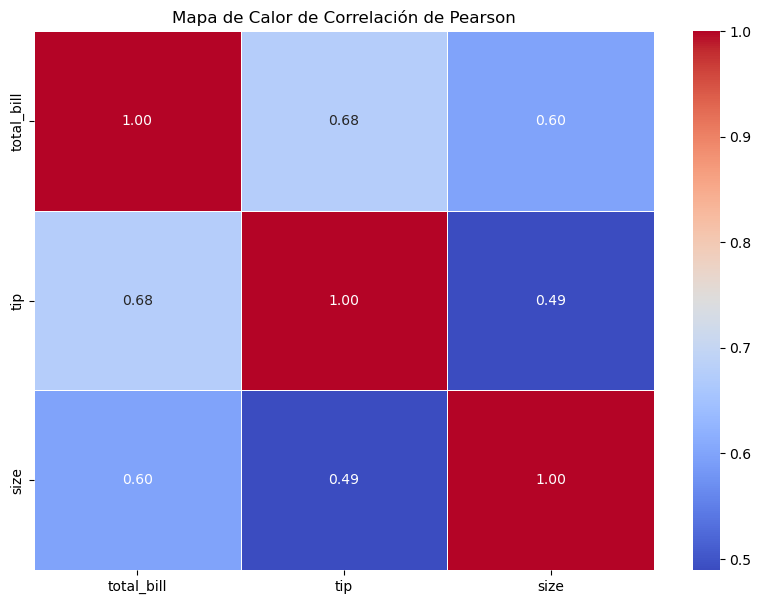

In [21]:
plt.figure(figsize=(10, 7))
sns.heatmap(matrizPearson, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlación de Pearson')
plt.show()

## <a id='fase-4'></a>Fase 4: Modelado con Regresión Lineal (OLS)

En esta fase, construiremos modelos de regresión por Mínimos Cuadrados Ordinarios (OLS) para predecir la propina (`tip`) basándonos en otras variables. Empezaremos con un modelo simple y luego construiremos uno múltiple.

### <a id='4-1'></a>4.1. Regresión Lineal Simple

El modelo más simple e intuitivo es predecir la propina (`tip`) usando únicamente el total de la cuenta (`total_bill`).


In [29]:
y = tipsDF['tip']
X_simple = tipsDF[['total_bill']]

X_simple_const = sm.add_constant(X_simple)

#ajustar el modelo OLS
modeloSimple = sm.OLS(y, X_simple_const).fit()

print(modeloSimple.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.457
Model:                            OLS   Adj. R-squared:                  0.454
Method:                 Least Squares   F-statistic:                     203.4
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           6.69e-34
Time:                        09:41:15   Log-Likelihood:                -350.54
No. Observations:                 244   AIC:                             705.1
Df Residuals:                     242   BIC:                             712.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9203      0.160      5.761      0.0

In [28]:
tipsDF = sns.load_dataset("tips")

y = tipsDF['tip']
X = tipsDF[['total_bill', 'size']]
X_const = sm.add_constant(X)

modelo = sm.OLS(y, X_const).fit()

print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           9.67e-34
Time:                        09:41:06   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6689      0.194      3.455      0.0

**Por cada dólar que aumenta el total_bill, la propina tiende a aumentar en 9.3 centavos, manteniendo constante el tamaño del grupo.

**Por cada persona adicional en el grupo (size), la propina tiende a aumentar en 19.3 centavos, manteniendo constante el total de la cuenta.


## <a id='fase-5'></a>Fase 5: Diagnóstico del Modelo y Conclusiones

Finalmente, es crucial diagnosticar nuestro `modelo` para asegurarnos de que sus resultados son fiables. Verificaremos los supuestos clave del modelo de regresión OLS.

### <a id='5-1'></a>5.1. Análisis de Supuestos de OLS

Un modelo OLS es válido si cumple con ciertos supuestos sobre los residuos (la diferencia entre los valores reales y los predichos por el modelo).

#### 1. Linealidad
Este supuesto ya lo verificamos visualmente en la **Fase 2** con el gráfico de dispersión (`regplot`), que mostraba una relación razonablemente lineal entre `total_bill` y `tip`.

#### 2. Normalidad de los Residuos
Los residuos del modelo deben seguir una distribución normal.

* **Gráfico Q-Q Plot:** Los puntos deben seguir de cerca la línea roja diagonal.


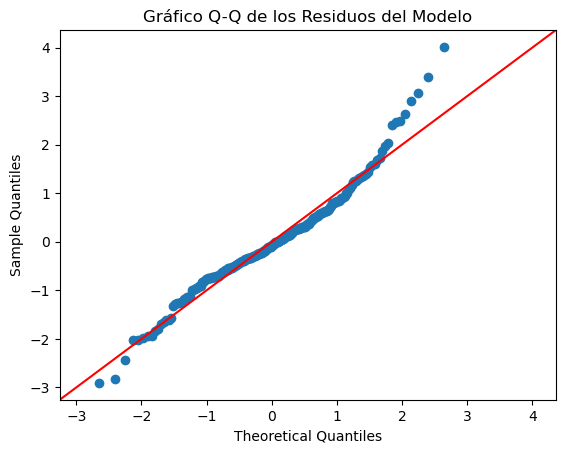

In [31]:
residuos = modelo.resid

fig = sm.qqplot(residuos, line='45', fit=True)
plt.title('Gráfico Q-Q de los Residuos del Modelo')
plt.show()

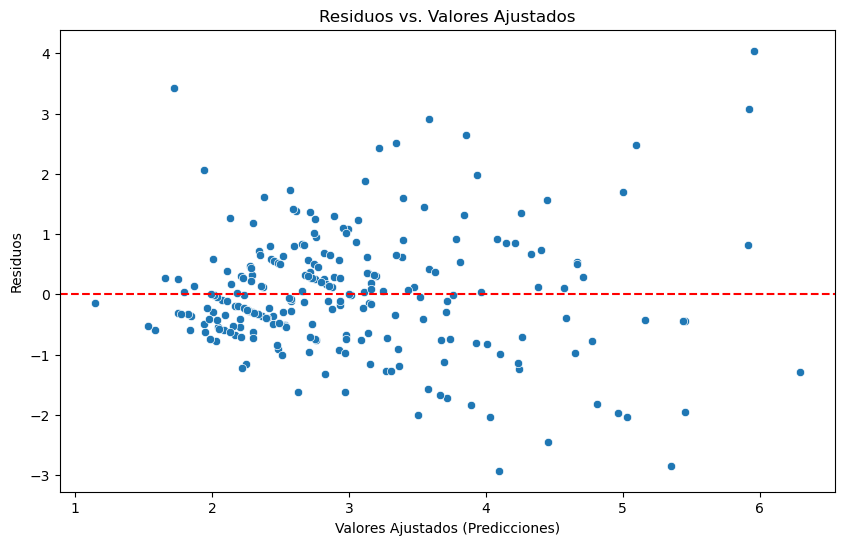

In [32]:
valoresAjustados = modelo.fittedvalues

plt.figure(figsize=(10, 6))
sns.scatterplot(x=valoresAjustados, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados (Predicciones)')
plt.ylabel('Residuos')
plt.show()

Alternativas cuando los supuestos no se cumplen.

Supuestos Cumplidos:

Linealidad: Se confirmó una relación lineal entre las variables a través de gráficos de dispersión.

Independencia de Residuos: Durbin-Watson (~2.1) indica ausencia de autocorrelación.

Multicolinealidad: No se detectó multicolinealidad severa entre los predictores total_bill y size.

Supuestos No Cumplidos:

Homocedasticidad: El supuesto fue violado. El gráfico de residuos contra valores ajustados mostró un patrón de cono, lo que indica la presencia de heterocedasticidad.

Normalidad de Residuos: El supuesto fue violado. La prueba de Jarque-Bera (Prob(JB) ≈ 0) y el gráfico Q-Q confirmaron que los residuos no siguen una distribución normal.

In [34]:

tipsDF['log_tip'] = np.log(tipsDF['tip'])

# log_tip como y
y_log = tipsDF['log_tip']
modeloLog = sm.OLS(y_log, X_const).fit()
print(modeloLog.summary())

                            OLS Regression Results                            
Dep. Variable:                log_tip   R-squared:                       0.437
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     93.65
Date:                Fri, 12 Sep 2025   Prob (F-statistic):           8.08e-31
Time:                        09:59:28   Log-Likelihood:                -73.110
No. Observations:                 244   AIC:                             152.2
Df Residuals:                     241   BIC:                             162.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2858      0.063      4.555      0.0